In [ ]:
/train.csv.zip

NameError: name 'train' is not defined

In [ ]:
import zipfile
import pandas as pd

# 1. File ko unzip karna
with zipfile.ZipFile('/train.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("1. File successfully unzipped!")

# 2. Unzip ki hui file ka path check karna aur data load karna
df = pd.read_csv('/content/train.csv')
print(f"2. Data successfully loaded! Shape: {df.shape}")

1. File successfully unzipped!
2. Data successfully loaded! Shape: (9800, 18)


--- STEP 1: DATA CLEANING ---
Data cleaned. Rows shifted from 9800 to 8655
Cleaned dataset saved as 'cleaned_superstore_sales.csv'

--- STEP 2: STATISTICAL SUMMARY ---
            Row ID                     Order Date  \
count  8655.000000                           3516   
mean   4916.320508  2017-03-18 22:02:27.440272640   
min       1.000000            2015-01-02 00:00:00   
25%    2454.500000            2016-04-09 18:00:00   
50%    4925.000000            2017-05-05 00:00:00   
75%    7362.500000            2018-03-09 00:00:00   
max    9800.000000            2018-12-11 00:00:00   
std    2830.949018                            NaN   

                           Ship Date   Postal Code        Sales  
count                           3379   8655.000000  8655.000000  
mean   2017-04-13 21:29:59.467298304  55388.652109    93.213330  
min              2015-01-04 00:00:00      0.000000     0.444000  
25%              2016-05-02 00:00:00  23320.000000    15.014000  
50%              2017-06

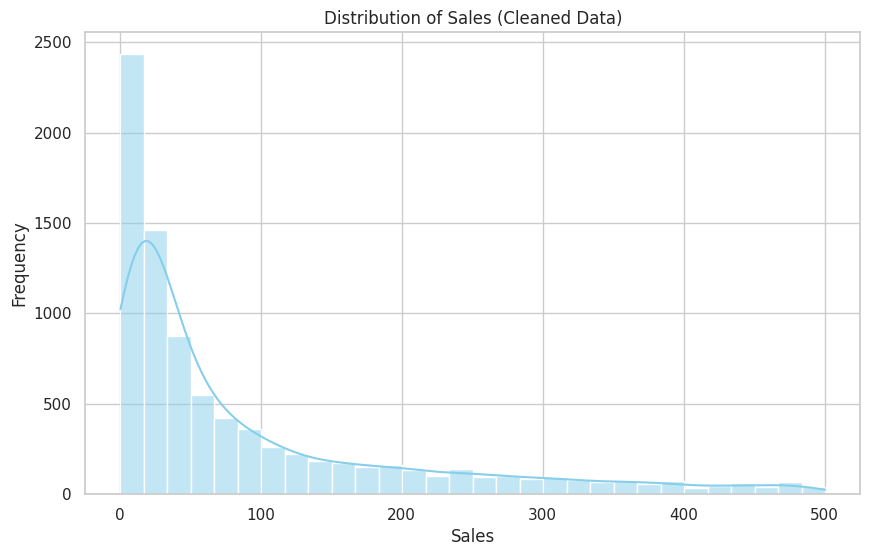

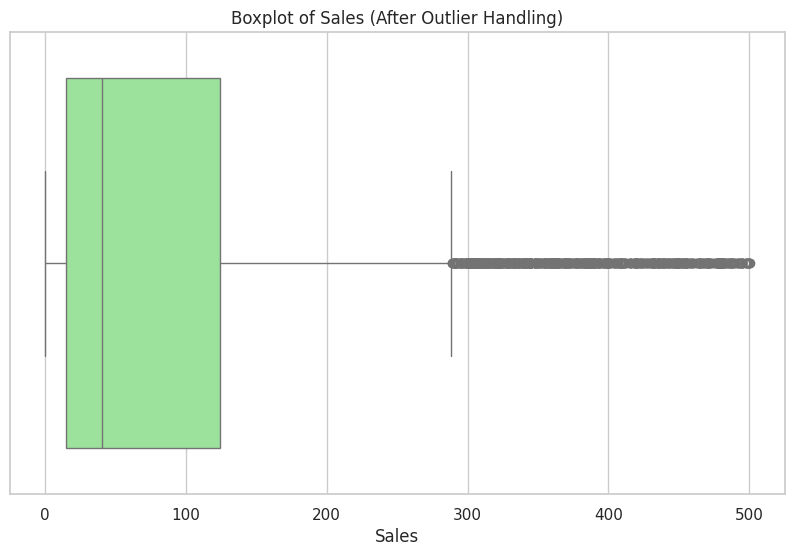

/tmp/ipykernel_5934/466207030.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=cat_sales, palette='muted')


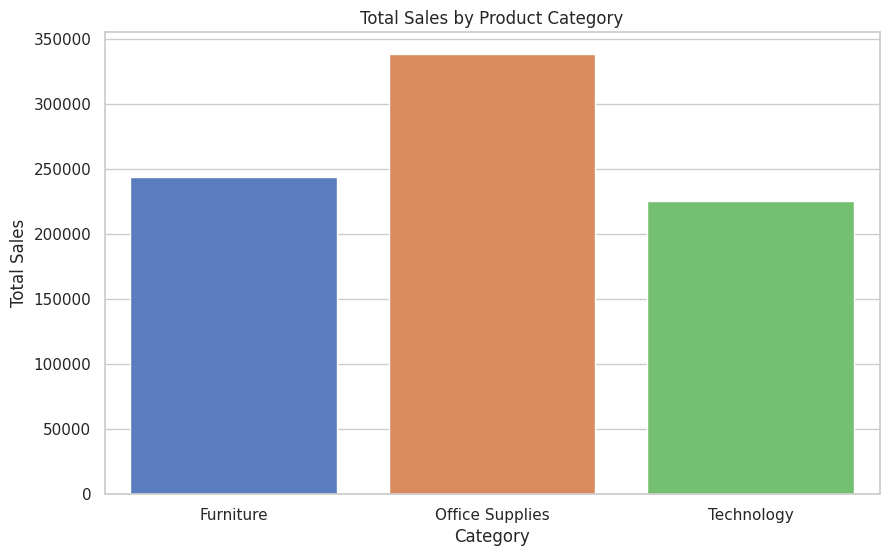

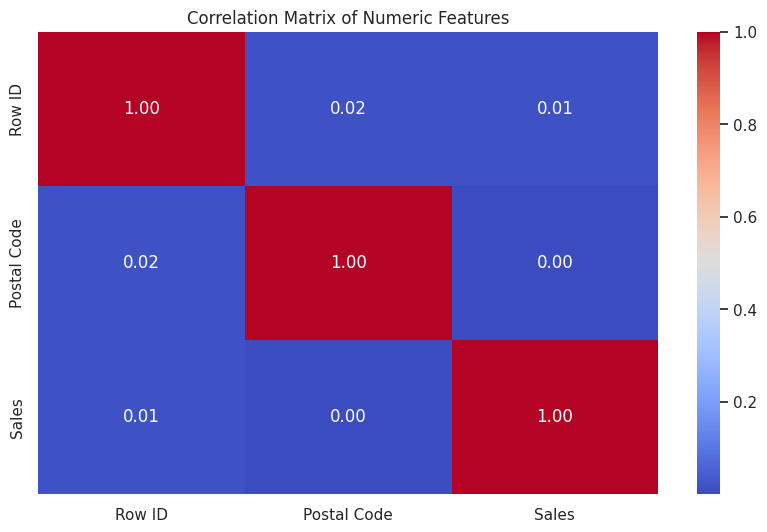

/tmp/ipykernel_5934/466207030.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['YearMonth'] = df_final['Order Date'].dt.to_period('M')


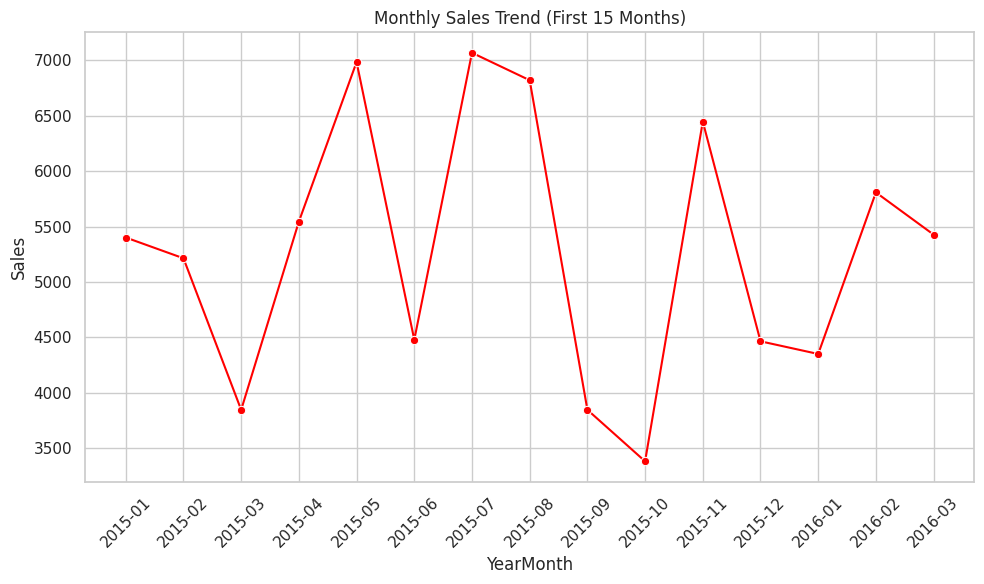


--- TASK 1 COMPLETE! ALL DELIVERABLES GENERATED ---


In [ ]:
# =====================================================================
# MAIN CLEANING & VISUALIZATION (Task 1 Complete)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Settings for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("--- STEP 1: DATA CLEANING ---")
# Missing values handle karna
df['Postal Code'] = df['Postal Code'].fillna(0)
df_cleaned = df.dropna().drop_duplicates()

# Dates fix karna
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], errors='coerce')
df_cleaned['Ship Date'] = pd.to_datetime(df_cleaned['Ship Date'], errors='coerce')

# Outliers Handling using IQR Method on 'Sales' column
Q1 = df_cleaned['Sales'].quantile(0.25)
Q3 = df_cleaned['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_final = df_cleaned[(df_cleaned['Sales'] >= lower_bound) & (df_final := df_cleaned['Sales'] <= upper_bound)]

# Cleaned data ko save karna (Deliverable requirement)
df_final.to_csv('cleaned_superstore_sales.csv', index=False)
print(f"Data cleaned. Rows shifted from {df.shape[0]} to {df_final.shape[0]}")
print("Cleaned dataset saved as 'cleaned_superstore_sales.csv'\n")

print("--- STEP 2: STATISTICAL SUMMARY ---")
print(df_final.describe())

print("\n--- STEP 3: GENERATING VISUALIZATIONS ---")

# 1. Histogram (Sales Distribution)
plt.figure()
sns.histplot(df_final['Sales'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Sales (Cleaned Data)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.savefig('01_sales_distribution.png')
plt.show()

# 2. Boxplot (Sales Outliers Check)
plt.figure()
sns.boxplot(x=df_final['Sales'], color='lightgreen')
plt.title('Boxplot of Sales (After Outlier Handling)')
plt.xlabel('Sales')
plt.savefig('02_sales_boxplot.png')
plt.show()

# 3. Bar Chart (Sales by Category)
plt.figure()
cat_sales = df_final.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(x='Category', y='Sales', data=cat_sales, palette='muted')
plt.title('Total Sales by Product Category')
plt.ylabel('Total Sales')
plt.savefig('03_sales_by_category.png')
plt.show()

# 4. Heatmap (Correlation Matrix)
plt.figure()
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
sns.heatmap(df_final[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.savefig('04_correlation_heatmap.png')
plt.show()

# 5. Line Chart (Sales Trend)
plt.figure()
df_final['YearMonth'] = df_final['Order Date'].dt.to_period('M')
trend = df_final.groupby('YearMonth')['Sales'].sum().reset_index()
trend['YearMonth'] = trend['YearMonth'].astype(str).head(15)
sns.lineplot(x='YearMonth', y='Sales', data=trend.head(15), marker='o', color='red')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend (First 15 Months)')
plt.tight_layout()
plt.savefig('05_sales_trend.png')
plt.show()

print("\n--- TASK 1 COMPLETE! ALL DELIVERABLES GENERATED ---")

In [ ]:
import pandas as pd
import sqlite3

print("--- STEP 1: CREATING DATABASE & TABLE ---")

# 1. SQLite database se connect karna (Ye memory mein ya local file banayega)
conn = sqlite3.connect('superstore.db')

# 2. Jo cleaned CSV file humne banayi thi use read karna
# Note: Agar aapne naya notebook khola hai, toh left side files panel mein 'cleaned_superstore_sales.csv' dubara upload kar dena agar na dikhe.
df_cleaned = pd.read_csv('/content/cleaned_superstore_sales.csv')

# Columns ke names se spaces hatana taaki SQL queries mein error na aaye
df_cleaned.columns = df_cleaned.columns.str.replace(' ', '_').str.replace('-', '_')

# 3. DataFrame ko SQL table mein convert karna
df_cleaned.to_sql('sales_table', conn, if_exists='replace', index=False)

print("Bhai, Database aur 'sales_table' ekdum ready hain!")

--- STEP 1: CREATING DATABASE & TABLE ---
Bhai, Database aur 'sales_table' ekdum ready hain!


In [10]:
import pandas as pd
import sqlite3

print("--- STEP 1: DATABASE CONNECTION ---")
# 1. Database connection set karna
conn = sqlite3.connect('superstore.db')

# 2. Uploaded cleaned CSV ko read karna
df_cleaned = pd.read_csv('/content/cleaned_superstore_sales.csv')

# Column names fix karna taaki SQL queries mein error na aaye
df_cleaned.columns = df_cleaned.columns.str.replace(' ', '_').str.replace('-', '_').str.replace('[', '').str.replace(']', '')

# 3. Table banana
df_cleaned.to_sql('sales_table', conn, if_exists='replace', index=False)
print("Bhai, Database aur table ekdum taiyar hain!\n")

def run_query(query_str, title):
    print(f"⚡ {title} ⚡")
    try:
        res = pd.read_sql_query(query_str, conn)
        print(res.head(5))
    except Exception as e:
        print(f"Query Check: {e}")
    print("-" * 50)
    return query_str

# -------------------------------------------------------------
# STEP 2: 10 ADVANCED BUSINESS QUERIES (Task 2 Core)
# -------------------------------------------------------------

q1 = run_query("""SELECT Product_ID, Product_Name, SUM(Sales) as Total_Sales FROM sales_table GROUP BY Product_ID ORDER BY Total_Sales DESC LIMIT 5;""", "Q1: Top 5 Products by Sales")

q2 = run_query("""SELECT Order_Date, SUM(Sales) as Daily_Sales FROM sales_table GROUP BY Order_Date ORDER BY Order_Date LIMIT 5;""", "Q2: Sales Trend")

q3 = run_query("""SELECT Customer_ID, Customer_Name, Total_Spend, CASE WHEN Total_Spend > 5000 THEN 'High Value' WHEN Total_Spend BETWEEN 2000 AND 5000 THEN 'Medium Value' ELSE 'Low Value' END as Customer_Segment FROM (SELECT Customer_ID, Customer_Name, SUM(Sales) as Total_Spend FROM sales_table GROUP BY Customer_ID) LIMIT 5;""", "Q3: Customer Segmentation")

q4 = run_query("""SELECT Category, Product_Name, Total_Sales, RANK() OVER (PARTITION BY Category ORDER BY Total_Sales DESC) as Sales_Rank FROM (SELECT Category, Product_Name, SUM(Sales) as Total_Sales FROM sales_table GROUP BY Category, Product_Name) LIMIT 5;""", "Q4: Product Rank within Category (RANK)")

q5 = run_query("""SELECT Customer_Name, Order_Date, Sales, ROW_NUMBER() OVER (PARTITION BY Customer_ID ORDER BY Order_Date DESC) as Transaction_Seq FROM sales_table LIMIT 5;""", "Q5: Transaction Sequence (ROW_NUMBER)")

q6 = run_query("""SELECT Order_Date, Sales, LAG(Sales, 1) OVER (ORDER BY Order_Date) as Previous_Sales FROM sales_table LIMIT 5;""", "Q6: Sales Comparison (LAG)")

q7 = run_query("""SELECT Customer_Name, Order_Date, Sales, LEAD(Sales, 1) OVER (PARTITION BY Customer_ID ORDER BY Order_Date ASC) as Next_Order_Sales FROM sales_table LIMIT 5;""", "Q7: Next Order Sales (LEAD)")

q8 = run_query("""WITH Category_Count AS (SELECT Category, COUNT(DISTINCT Order_ID) as Total_Orders FROM sales_table GROUP BY Category) SELECT * FROM Category_Count ORDER BY Total_Orders DESC;""", "Q8: Orders by Category (CTE)")

q9 = run_query("""SELECT Category, Sub_Category, SUM(Sales) as Sub_Cat_Sales FROM sales_table GROUP BY Category, Sub_Category HAVING Sub_Cat_Sales > 5000 ORDER BY Sub_Cat_Sales DESC LIMIT 5;""", "Q9: High Performing Sub-Categories")

q10 = run_query("""SELECT Region, State, Total_State_Sales FROM (SELECT Region, State, SUM(Sales) as Total_State_Sales, RANK() OVER (PARTITION BY Region ORDER BY SUM(Sales) DESC) as Rank FROM sales_table GROUP BY Region, State) WHERE Rank = 1;""", "Q10: Top State per Region")

# Reusable SQL script file banana (Deliverable)
sql_content = f"-- Task 2 Queries\n-- Q1\n{q1}\n-- Q2\n{q2}\n-- Q3\n{q3}\n-- Q4\n{q4}\n-- Q5\n{q5}\n-- Q6\n{q6}\n-- Q7\n{q7}\n-- Q8\n{q8}\n-- Q9\n{q9}\n-- Q10\n{q10}"
with open('task_2_queries.sql', 'w') as f:
    f.write(sql_content)
print("\n--- TASK 2 COMPLETE: 'task_2_queries.sql' SAVED SUCCESSFULLY ---")

--- STEP 1: DATABASE CONNECTION ---
Bhai, Database aur table ekdum taiyar hain!

⚡ Q1: Top 5 Products by Sales ⚡
        Product_ID                                      Product_Name  \
0  FUR-CH-10003774   Global Wood Trimmed Manager's Task Chair, Khaki   
1  FUR-CH-10002647        Situations Contoured Folding Chairs, 4/Set   
2  FUR-CH-10002880         Global High-Back Leather Tilter, Burgundy   
3  TEC-PH-10003012  Nortel Meridian M3904 Professional Digital phone   
4  OFF-BI-10004632               Ibico Hi-Tech Manual Binding System   

   Total_Sales  
0     3621.004  
1     2959.866  
2     2841.069  
3     2802.618  
4     2790.683  
--------------------------------------------------
⚡ Q2: Sales Trend ⚡
   Order_Date  Daily_Sales
0        None  480120.9759
1  2015-01-02     468.9000
2  2015-01-03    1569.0350
3  2015-01-04     119.8880
4  2015-01-06     801.4800
--------------------------------------------------
⚡ Q3: Customer Segmentation ⚡
  Customer_ID  Customer_Name  Total_Sp

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

print("--- STEP 1: LOADING DATA FOR VISUALIZATION ---")
# Data load karna
df = pd.read_csv('/content/cleaned_superstore_sales.csv')

# -------------------------------------------------------------
# 1. MATPLOTLIB & SEABORN (Static Plots)
# -------------------------------------------------------------
print("Generating Static Plots...")

# Plot 1: Category wise Sales (Bar Plot using Seaborn)
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='viridis')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('category_sales_matplotlib.png', dpi=300)
plt.close()

# Plot 2: Sub-Category Sales Breakdown (Boxen/Box Plot using Seaborn)
plt.figure(figsize=(12, 6))
sns.boxenplot(x='Sub-Category', y='Sales', data=df[df['Sales'] < 500])  # Filtering extreme outliers for visibility
plt.xticks(rotation=45)
plt.title('Sales Distribution by Sub-Category')
plt.tight_layout()
plt.savefig('subcategory_sales_distribution.png', dpi=300)
plt.close()

# -------------------------------------------------------------
# 2. PLOTLY (Interactive Plots)
# -------------------------------------------------------------
print("Generating Interactive Plots...")

# Plot 3: Interactive Line Chart for Sales Trend over Time
df['Order Date'] = pd.to_datetime(df['Order Date'])
df_trend = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
df_trend['Order Date'] = df_trend['Order Date'].astype(str)

fig_trend = px.line(df_trend, x='Order Date', y='Sales', title='Monthly Sales Trend over Time',
                    labels={'Order Date': 'Month', 'Sales': 'Total Sales'})
fig_trend.update_layout(template='plotly_dark')
fig_trend.write_html('monthly_sales_trend_interactive.html')

# Plot 4: Interactive Category breakdown (Donut Chart)
df_cat = df.groupby('Category')['Sales'].sum().reset_index()
fig_donut = px.pie(df_cat, values='Sales', names='Category', hole=0.4,
                   title='Sales Breakdown by Product Category', color_discrete_sequence=px.colors.sequential.RdBu)
fig_donut.write_html('category_breakdown_donut_interactive.html')

print("\n--- PYTHON VISUALIZATION COMPLETE ---")
print("Files Generated successfully in left panel:")
print("1. category_sales_matplotlib.png\n2. subcategory_sales_distribution.png\n3. monthly_sales_trend_interactive.html\n4. category_breakdown_donut_interactive.html")

--- STEP 1: LOADING DATA FOR VISUALIZATION ---
Generating Static Plots...


/tmp/ipykernel_5934/1200596847.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='viridis')
/tmp/ipykernel_5934/1200596847.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='viridis')


Generating Interactive Plots...

--- PYTHON VISUALIZATION COMPLETE ---
Files Generated successfully in left panel:
1. category_sales_matplotlib.png
2. subcategory_sales_distribution.png
3. monthly_sales_trend_interactive.html
4. category_breakdown_donut_interactive.html
